# MOSA Improvement Analysis — Model Comparison

Four-config comparison:
1. **Random Forest — overlap + original** (RF baseline)
2. **Random Forest — expanded + mosa_all** (RF + MOSA)
3. **TabPFN — overlap + original** (TabPFN baseline)
4. **TabPFN — expanded + mosa_all** (TabPFN + MOSA)

Primary metric: Pearson's r.

In [1]:
import json
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

TABPFN_ROOT = pathlib.Path(
    "../reports/tabpfn/feature_augmentation/20260313_162348"
)
RF_ROOT = pathlib.Path(
    "../reports/random_forest/feature_augmentation/20260313_162348"
)

CONFIGS = {
    "rf_overlap_original":     (RF_ROOT,     "overlap", "original"),
    "tabpfn_overlap_original": (TABPFN_ROOT, "overlap", "original"),
    "rf_expanded_mosa":        (RF_ROOT,     "expanded", "mosa_all"),
    "tabpfn_expanded_mosa":    (TABPFN_ROOT, "expanded", "mosa_all"),
}

CONFIG_LABELS = {
    "rf_overlap_original":     "RF overlap+original",
    "tabpfn_overlap_original": "TabPFN overlap+original",
    "rf_expanded_mosa":        "RF expanded+mosa_all",
    "tabpfn_expanded_mosa":    "TabPFN expanded+mosa_all",
}

CONFIG_COLORS = {
    "rf_overlap_original":     "#8fbc8f",
    "tabpfn_overlap_original": "#7eaed1",
    "rf_expanded_mosa":        "#6b8e6b",
    "tabpfn_expanded_mosa":    "#e27d60",
}

TARGET_FAMILIES = ["drugresponse", "crisprcas9"]
FAMILY_LABELS = {"drugresponse": "Drug Response", "crisprcas9": "CRISPR"}

## 1. Load summary-level metrics

In [2]:
rows = []
for family in TARGET_FAMILIES:
    for cfg_key, (root, frame, variant) in CONFIGS.items():
        p = root / family / frame / variant / "test_metrics_summary.json"
        with open(p) as f:
            d = json.load(f)
        d["config"] = cfg_key
        d["config_label"] = CONFIG_LABELS[cfg_key]
        d["family_label"] = FAMILY_LABELS[family]
        rows.append(d)

summary = pd.DataFrame(rows)
display(summary[
    ["family_label", "config_label", "model_name", "train_n", "test_n",
     "test_pearsonr", "test_rmse"]
])

,family_label,config_label,model_name,train_n,test_n,test_pearsonr,test_rmse
0,Drug Response,RF overlap+original,random_forest,95,24,0.234567,0.175207
1,Drug Response,TabPFN overlap+original,NaN,95,24,0.220727,0.175167
2,Drug Response,RF expanded+mosa_all,random_forest,231,24,0.268983,0.173671
3,Drug Response,TabPFN expanded+mosa_all,NaN,231,24,0.323140,0.168927
4,CRISPR,RF overlap+original,random_forest,95,24,0.151016,0.661047
5,CRISPR,TabPFN overlap+original,NaN,95,24,0.143561,0.659954
6,CRISPR,RF expanded+mosa_all,random_forest,132,24,0.196188,0.659458
7,CRISPR,TabPFN expanded+mosa_all,NaN,132,24,0.213875,0.649041


## 2. Compute improvement (%) for Pearson's r

In [3]:
improvement_rows = []

for family in TARGET_FAMILIES:
    s = summary[summary["target_family"] == family]
    rf_base    = s[s["config"] == "rf_overlap_original"].iloc[0]
    rf_mosa    = s[s["config"] == "rf_expanded_mosa"].iloc[0]
    tabpfn_base = s[s["config"] == "tabpfn_overlap_original"].iloc[0]
    tabpfn_mosa = s[s["config"] == "tabpfn_expanded_mosa"].iloc[0]

    for metric in ["test_pearsonr"]:
        rv  = rf_base[metric]
        rmv = rf_mosa[metric]
        bv  = tabpfn_base[metric]
        mv  = tabpfn_mosa[metric]
        improvement_rows.append({
            "Family": FAMILY_LABELS[family],
            "Metric": metric,
            "RF base": round(rv, 4),
            "RF mosa": round(rmv, 4),
            "TabPFN base": round(bv, 4),
            "TabPFN mosa": round(mv, 4),
            "Δ TabPFN mosa vs RF base": round(mv - rv, 4),
            "% vs RF base": round((mv - rv) / abs(rv) * 100, 1),
        })

improvement_df = pd.DataFrame(improvement_rows)
display(improvement_df)

,Family,Metric,RF base,RF mosa,TabPFN base,TabPFN mosa,Δ TabPFN mosa vs RF base,% vs RF base
0,Drug Response,test_pearsonr,0.2346,0.2690,0.2207,0.3231,0.0886,37.8
1,CRISPR,test_pearsonr,0.1510,0.1962,0.1436,0.2139,0.0629,41.6


## 3. Load per-target Pearson's r

In [4]:
per_target = {}
for family in TARGET_FAMILIES:
    per_target[family] = {}
    for cfg_key, (root, frame, variant) in CONFIGS.items():
        p = root / family / frame / variant / "test_metrics_per_target.csv"
        per_target[family][cfg_key] = pd.read_csv(p)

for family in TARGET_FAMILIES:
    rf      = per_target[family]["rf_overlap_original"][["target", "test_pearsonr"]]
    rf_mosa = per_target[family]["rf_expanded_mosa"][["target", "test_pearsonr"]]
    base    = per_target[family]["tabpfn_overlap_original"][["target", "test_pearsonr"]]
    mosa    = per_target[family]["tabpfn_expanded_mosa"][["target", "test_pearsonr"]]

    merged = (
        rf.rename(columns={"test_pearsonr": "r_rf"})
        .merge(rf_mosa.rename(columns={"test_pearsonr": "r_rf_mosa"}), on="target")
        .merge(base.rename(columns={"test_pearsonr": "r_tabpfn_base"}), on="target")
        .merge(mosa.rename(columns={"test_pearsonr": "r_tabpfn_mosa"}), on="target")
    )
    merged["delta_mosa_vs_rf"] = merged["r_tabpfn_mosa"] - merged["r_rf"]
    per_target[family]["merged"] = merged

    label = FAMILY_LABELS[family]
    d = merged["delta_mosa_vs_rf"]
    print(f"\n{label}: {len(merged)} targets")
    print(f"  TabPFN MOSA vs RF baseline: improved {(d > 0).sum()}, "
          f"worsened {(d < 0).sum()}, median Δr {d.median():.4f}")


Drug Response: 500 targets
  TabPFN MOSA vs RF baseline: improved 350, worsened 150, median Δr 0.0905

CRISPR: 500 targets
  TabPFN MOSA vs RF baseline: improved 319, worsened 181, median Δr 0.0558


## 4. Bar chart — Summary metrics comparison

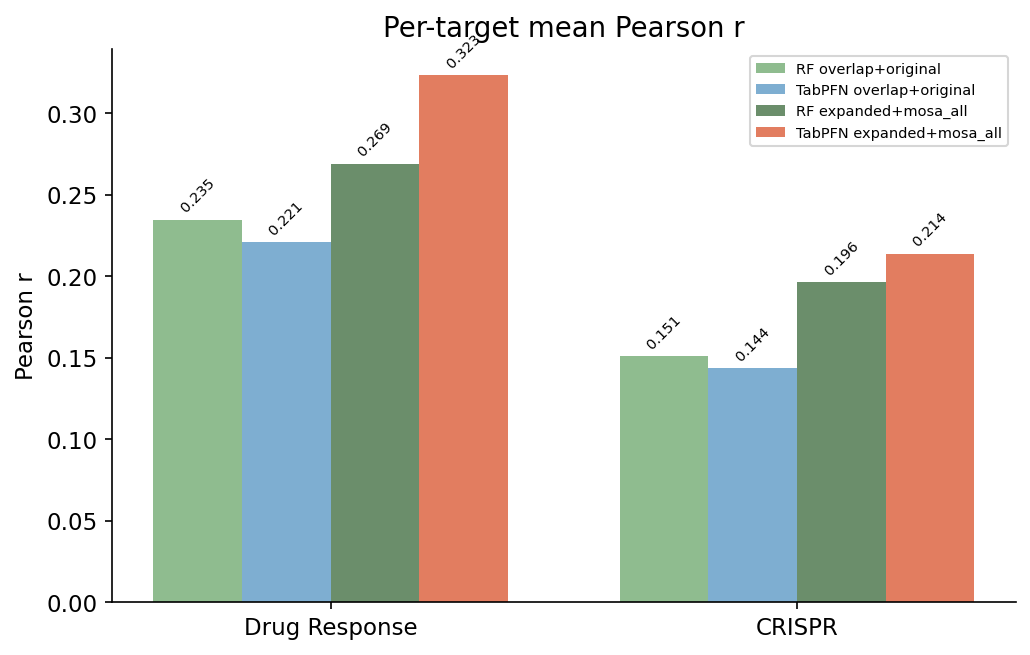

In [5]:
cfg_keys = list(CONFIGS.keys())
n_cfgs = len(cfg_keys)
width = 0.19

def _bar_chart(values_per_cfg, title, ylabel="Pearson r"):
    """Draw a grouped bar chart; values_per_cfg is {cfg_key: [val_per_family]}."""
    fig, ax = plt.subplots(figsize=(7, 4.5))
    x = np.arange(len(TARGET_FAMILIES))
    for i, cfg_key in enumerate(cfg_keys):
        offset = (i - (n_cfgs - 1) / 2) * width
        bars = ax.bar(x + offset, values_per_cfg[cfg_key], width,
                      label=CONFIG_LABELS[cfg_key],
                      color=CONFIG_COLORS[cfg_key])
        for bar, v in zip(bars, values_per_cfg[cfg_key]):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                    f"{v:.3f}", ha="center", va="bottom", fontsize=7,
                    rotation=45)
    ax.set_xticks(x)
    ax.set_xticklabels([FAMILY_LABELS[f] for f in TARGET_FAMILIES])
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=7, loc="upper right")
    fig.tight_layout()
    plt.show()

mean_vals = {
    cfg_key: [
        summary[
            (summary["target_family"] == fam) & (summary["config"] == cfg_key)
        ]["test_pearsonr"].values[0]
        for fam in TARGET_FAMILIES
    ]
    for cfg_key in cfg_keys
}
_bar_chart(mean_vals, "Per-target mean Pearson r")

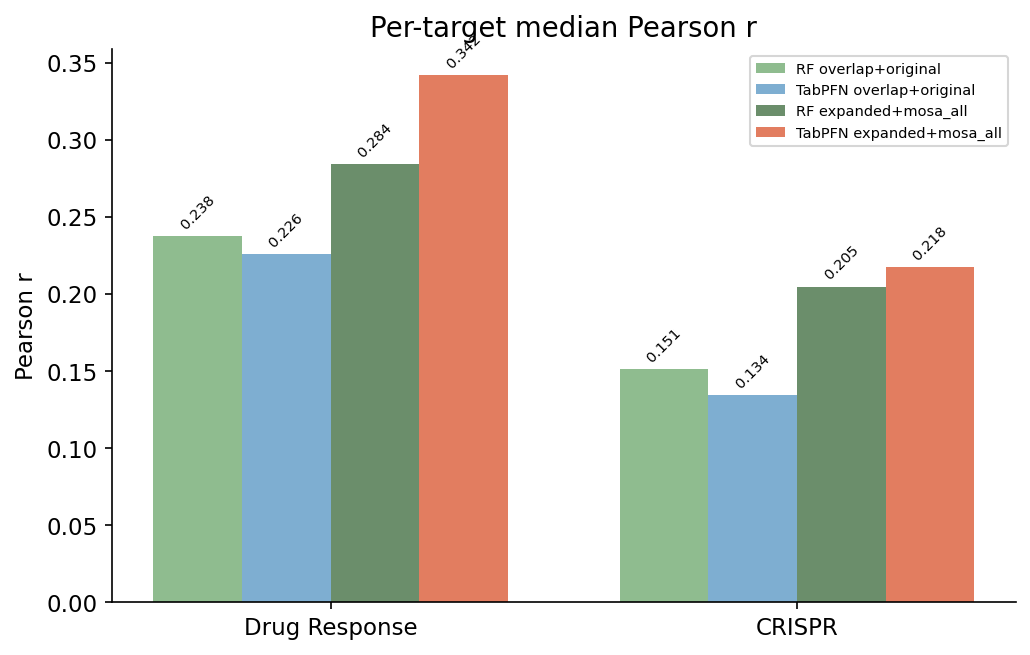

In [6]:
median_vals = {
    cfg_key: [
        per_target[fam][cfg_key]["test_pearsonr"].median()
        for fam in TARGET_FAMILIES
    ]
    for cfg_key in cfg_keys
}
_bar_chart(median_vals, "Per-target median Pearson r")

## 5. Per-target scatter — baseline vs MOSA

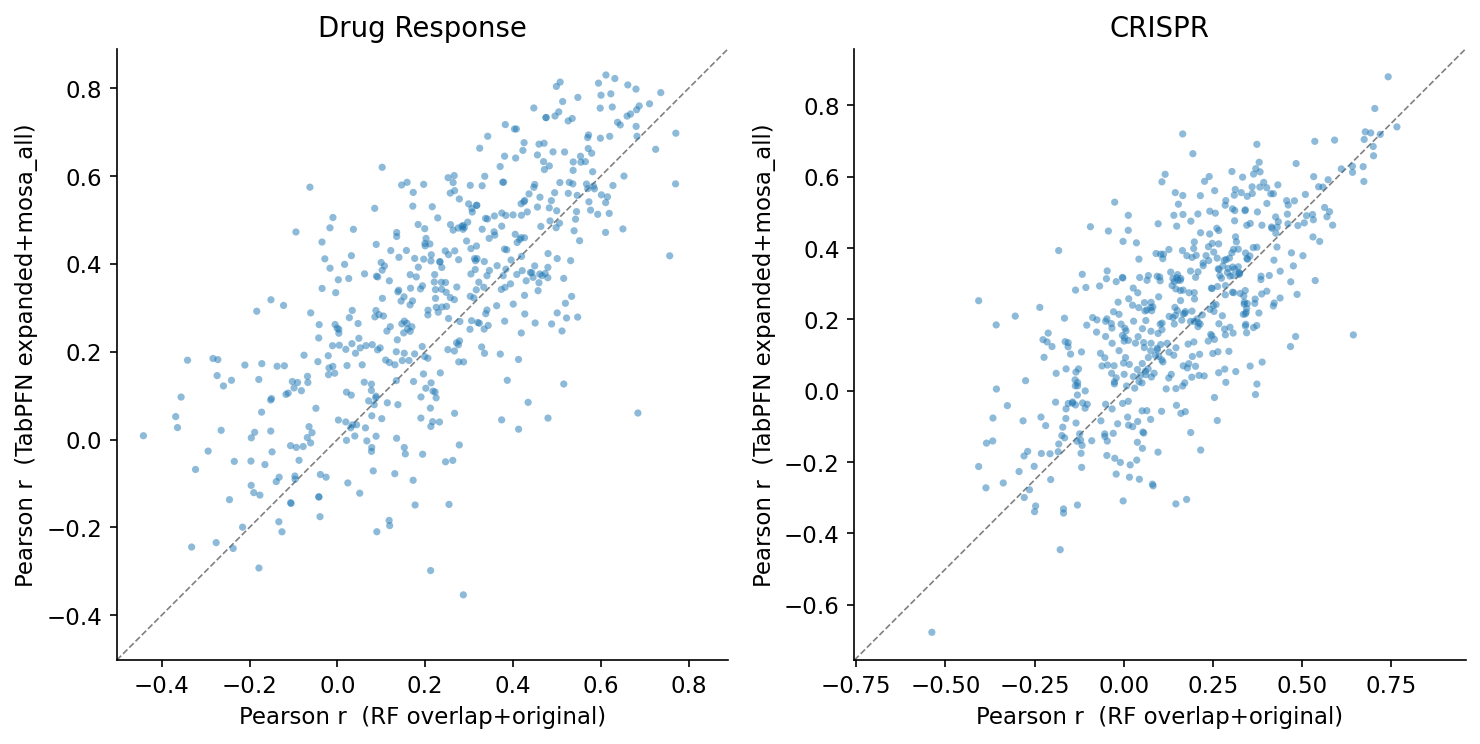

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, family in zip(axes, TARGET_FAMILIES):
    m = per_target[family]["merged"]
    ax.scatter(m["r_rf"], m["r_tabpfn_mosa"],
               s=12, alpha=0.5, edgecolors="none")
    lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]),
            max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims, "--", color="grey", linewidth=0.8, zorder=0)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel("Pearson r  (RF overlap+original)")
    ax.set_ylabel("Pearson r  (TabPFN expanded+mosa_all)")
    ax.set_title(FAMILY_LABELS[family])
    ax.set_aspect("equal")

fig.tight_layout()
plt.show()

## 6. Histogram — per-target delta Pearson r

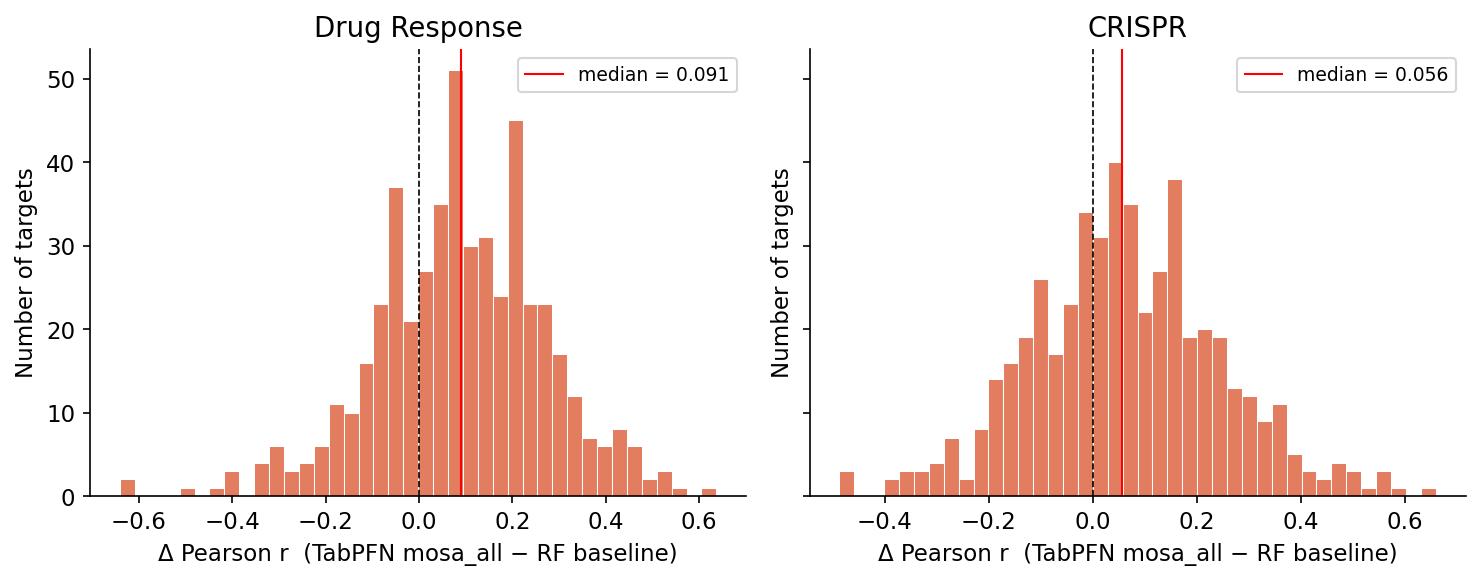

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

for ax, family in zip(axes, TARGET_FAMILIES):
    m = per_target[family]["merged"]
    d = m["delta_mosa_vs_rf"]
    ax.hist(d, bins=40, edgecolor="white", linewidth=0.5, color="#e27d60")
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.axvline(d.median(), color="red", linewidth=1, linestyle="-",
               label=f"median = {d.median():.3f}")
    ax.set_xlabel("Δ Pearson r  (TabPFN mosa_all − RF baseline)")
    ax.set_ylabel("Number of targets")
    ax.set_title(FAMILY_LABELS[family])
    ax.legend(fontsize=9)

fig.tight_layout()
plt.show()

## 7. Key numbers for the abstract

In [9]:
print("=" * 70)
print("KEY NUMBERS — MODEL COMPARISON (RF baseline)")
print("=" * 70)

for family in TARGET_FAMILIES:
    s = summary[summary["target_family"] == family]
    rf      = s[s["config"] == "rf_overlap_original"].iloc[0]
    rf_mosa = s[s["config"] == "rf_expanded_mosa"].iloc[0]
    base    = s[s["config"] == "tabpfn_overlap_original"].iloc[0]
    mosa    = s[s["config"] == "tabpfn_expanded_mosa"].iloc[0]

    label = FAMILY_LABELS[family]
    print(f"\n{'—'*70}")
    print(f"  {label}")
    print(f"{'—'*70}")

    for metric, nice_name in [
        ("test_pearsonr", "Per-target mean Pearson r"),
    ]:
        rv  = rf[metric]
        rmv = rf_mosa[metric]
        bv  = base[metric]
        mv  = mosa[metric]
        print(f"\n  {nice_name}:")
        print(f"    RF overlap+orig:     {rv:.4f}  (baseline)")
        print(f"    RF exp+mosa:         {rmv:.4f}  (Δ vs RF base: {rmv - rv:+.4f}, {(rmv - rv)/abs(rv)*100:+.1f}%)")
        print(f"    TabPFN overlap+orig: {bv:.4f}  (Δ vs RF base: {bv - rv:+.4f}, {(bv - rv)/abs(rv)*100:+.1f}%)")
        print(f"    TabPFN exp+mosa:     {mv:.4f}  (Δ vs RF base: {mv - rv:+.4f}, {(mv - rv)/abs(rv)*100:+.1f}%)")

    m_merged = per_target[family]["merged"]
    d = m_merged["delta_mosa_vs_rf"]
    frac = (d > 0).mean() * 100
    print(f"\n  TabPFN MOSA vs RF baseline (per-target):")
    print(f"    {frac:.0f}% of targets improved, median Δr = {d.median():.4f}")

print("\n" + "=" * 70)

KEY NUMBERS — MODEL COMPARISON (RF baseline)

——————————————————————————————————————————————————————————————————————
  Drug Response
——————————————————————————————————————————————————————————————————————

  Per-target mean Pearson r:
    RF overlap+orig:     0.2346  (baseline)
    RF exp+mosa:         0.2690  (Δ vs RF base: +0.0344, +14.7%)
    TabPFN overlap+orig: 0.2207  (Δ vs RF base: -0.0138, -5.9%)
    TabPFN exp+mosa:     0.3231  (Δ vs RF base: +0.0886, +37.8%)

  TabPFN MOSA vs RF baseline (per-target):
    70% of targets improved, median Δr = 0.0905

——————————————————————————————————————————————————————————————————————
  CRISPR
——————————————————————————————————————————————————————————————————————

  Per-target mean Pearson r:
    RF overlap+orig:     0.1510  (baseline)
    RF exp+mosa:         0.1962  (Δ vs RF base: +0.0452, +29.9%)
    TabPFN overlap+orig: 0.1436  (Δ vs RF base: -0.0075, -4.9%)
    TabPFN exp+mosa:     0.2139  (Δ vs RF base: +0.0629, +41.6%)

  TabPFN MOSA v